In [1]:
import os, sys, json
import matplotlib.pyplot as plt
sys.path.append("..")
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

/home/zczhang/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# read from json
data = None
experiment_name = "fig8a"
with open("../../../output/oscar-nsdi26/experiments/" + experiment_name + ".json", "r") as f:
    data = json.load(f)

In [3]:
# Calculate the send rate from data{flowStatistics:[0:4]:sentPkt:[timeNs,sizeByte]}
# The send rate is calculated by the number Bytes sent in each time interval
send_rate_interval_ns = 1e4  # 10us
send_rate = []
flow_num = 2
for i in range(flow_num):
    send_rate.append([])
    wnd_start = data["flowStatistics"][i]["sentPkt"][0]["timeNs"]
    # the first point
    send_rate[i].append({"timeNs": wnd_start, "sendRateGbps": 0})
    wnd_data = 0
    for sentPkt in data["flowStatistics"][i]["sentPkt"]:
        if sentPkt["timeNs"] - wnd_start > 2*send_rate_interval_ns:
            # Gbps = bpns
            send_rate[i].append({"timeNs": wnd_start,
                                "sendRateGbps": wnd_data * 8 / (sentPkt["timeNs"] - wnd_start)})
            send_rate[i].append({"timeNs": sentPkt["timeNs"],
                                "sendRateGbps": wnd_data * 8 / (sentPkt["timeNs"] - wnd_start)})
            wnd_start = sentPkt["timeNs"]
            wnd_data = 0
        elif sentPkt["timeNs"] - wnd_start > send_rate_interval_ns:
            # Gbps = bpns
            send_rate[i].append({"timeNs": wnd_start + (sentPkt["timeNs"] - wnd_start)/2,
                                "sendRateGbps": wnd_data * 8 / (sentPkt["timeNs"] - wnd_start)})
            wnd_start = sentPkt["timeNs"]
            wnd_data = 0
        wnd_data += sentPkt["sizeByte"]
    # the last point
    send_rate[i].append({"timeNs": wnd_start + send_rate_interval_ns/2,
                         "sendRateGbps": 0})


switch_idx = 0
port_idx = 16
queue_idx = 0

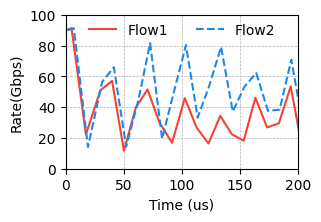

In [4]:
# draw the send rate in a new figure
fig = plt.figure(figsize=(3, 2))

ax1 = fig.add_subplot(111)
ax1.set_xlabel("Time (us)")
ax1.set_ylabel("Rate(Gbps)")

time_shift = 100e3

color_rate = ["#F44336", "#1E88E5"]
color_queue = ["#4E342E", "#FB8C00"]
line = ["-", "--"]

ax1.plot([s["timeNs"]/1e3 - time_shift for s in send_rate[0]],
         [90] + [s["sendRateGbps"] for s in send_rate[0]][1:], label="Flow1", color=color_rate[0], linestyle=line[0])
ax1.plot([s["timeNs"]/1e3 - time_shift for s in send_rate[1]],
         [90] + [s["sendRateGbps"] for s in send_rate[1]][1:], label="Flow2", color=color_rate[1], linestyle=line[1])
ax1.grid(True, linestyle='--', linewidth=0.5, which='both', axis='both')

ax1.set_xlim(0, 200)
ax1.set_ylim(0, 100)

plt.legend(loc='center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.9), prop={'size': 10})

plt.savefig("../figures/" + "fig8a" +
             ".pdf", bbox_inches='tight', dpi=600, format='pdf')